# Question 10 — Bilateral Filtering
- (a) Manual bilateral filter implementation
- (b) Gaussian smoothing using cv.GaussianBlur()
- (c) Bilateral filtering using cv.bilateralFilter()
- (d) Compare manual vs OpenCV bilateral

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def show_gray(img, title=''):
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

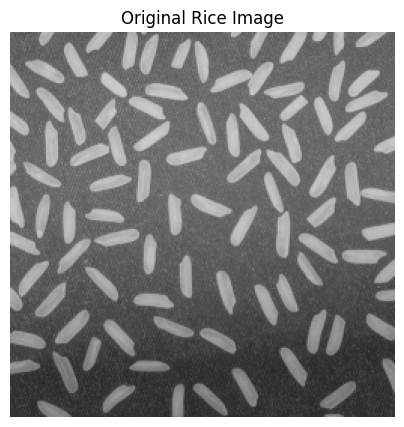

Image shape: (256, 256)


In [2]:
# Load rice image as grayscale
img = cv.imread('images/rice.png', cv.IMREAD_GRAYSCALE)
assert img is not None
show_gray(img, 'Original Rice Image')
print('Image shape:', img.shape)

## (a) Manual Bilateral Filter

The bilateral filter is an edge-preserving smoothing filter. Unlike Gaussian which only weights pixels by **spatial distance**, bilateral weights by both:

$$BF[I]_p = \frac{1}{W_p} \sum_{q \in S} G_{\sigma_s}(\|p-q\|) \cdot G_{\sigma_r}(|I_p - I_q|) \cdot I_q$$

- $G_{\sigma_s}$ — **spatial kernel**: pixels far away contribute less
- $G_{\sigma_r}$ — **range kernel**: pixels with very different intensity contribute less
- $W_p$ — normalization factor (sum of all weights)

This means pixels **across an edge** (large intensity difference) get near-zero weight, so edges are preserved.

In [3]:
def bilateral_filter_manual(img, diameter, sigma_s, sigma_r):
    """
    Manual bilateral filter for grayscale images.

    Parameters
    ----------
    img      : np.ndarray  — grayscale input image
    diameter : int         — kernel diameter (must be odd)
    sigma_s  : float       — spatial standard deviation
    sigma_r  : float       — range (intensity) standard deviation
    """
    img   = img.astype(np.float32)
    pad   = diameter // 2
    padded = cv.copyMakeBorder(img, pad, pad, pad, pad, cv.BORDER_REFLECT)
    out   = np.zeros_like(img)

    # Spatial kernel — same for every pixel
    x, y  = np.mgrid[-pad:pad+1, -pad:pad+1]
    spatial = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+diameter, j:j+diameter]

            # Range kernel — depends on intensity difference from center pixel
            range_k = np.exp(-((region - img[i, j])**2) / (2 * sigma_r**2))

            weights = spatial * range_k
            weights /= weights.sum()          # normalize
            out[i, j] = np.sum(weights * region)

    return np.clip(out, 0, 255).astype(np.uint8)

print('Manual bilateral filter defined.')
print('Note: This runs pixel-by-pixel so may take a minute on large images.')

Manual bilateral filter defined.
Note: This runs pixel-by-pixel so may take a minute on large images.


Running manual bilateral filter...
Done!


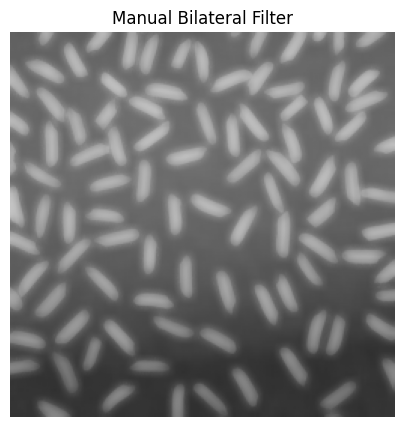

In [4]:
# Parameters
diameter = 9
sigma_s  = 21    # spatial std — controls smoothing area
sigma_r  = 75    # range std   — controls edge sensitivity

# Run manual bilateral filter
# Downscale first for speed, then work on smaller image
img_small = cv.resize(img, (256, 256))
print('Running manual bilateral filter...')
manual_bilateral = bilateral_filter_manual(img_small, diameter, sigma_s, sigma_r)
print('Done!')
show_gray(manual_bilateral, 'Manual Bilateral Filter')

## (b) Gaussian Smoothing — cv.GaussianBlur()

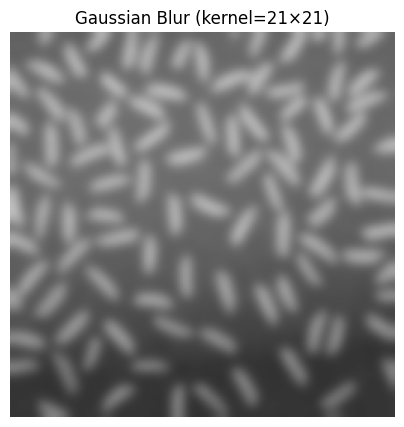

True

In [5]:
# (b) Gaussian smoothing — blurs everything including edges
gaussian = cv.GaussianBlur(img, (sigma_s, sigma_s), 0)
show_gray(gaussian, f'Gaussian Blur (kernel={sigma_s}×{sigma_s})')
cv.imwrite('outputs/q10b_gaussian.png', gaussian)

## (c) Bilateral Filtering — cv.bilateralFilter()

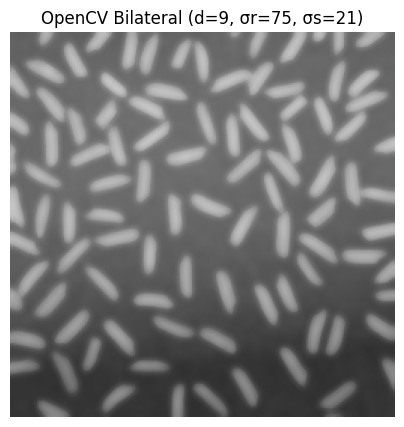

True

In [6]:
# (c) OpenCV bilateral filter
opencv_bilateral = cv.bilateralFilter(img, diameter, sigma_r, sigma_s)
show_gray(opencv_bilateral, f'OpenCV Bilateral (d={diameter}, σr={sigma_r}, σs={sigma_s})')
cv.imwrite('outputs/q10c_opencv_bilateral.png', opencv_bilateral)

## (d) Full Comparison — All Methods

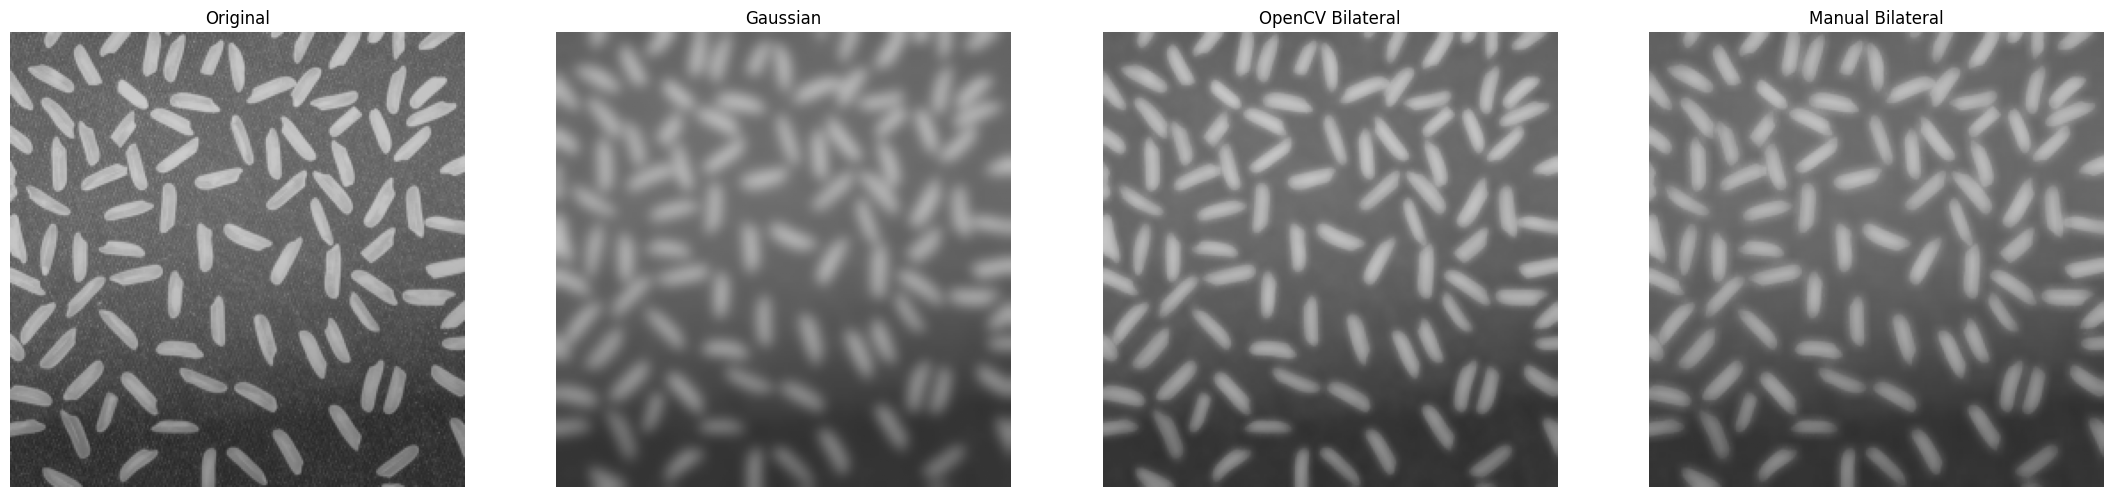

Key observations:
  Gaussian      : smooths everything — rice grain edges are blurred
  OpenCV bilateral : smooths background, preserves grain edges sharply
  Manual bilateral : matches OpenCV result closely — minor differences
                     due to border handling and floating-point rounding


In [7]:
# Resize all to same size for fair comparison display
h, w = img_small.shape
orig_s     = cv.resize(img,              (w, h))
gauss_s    = cv.resize(gaussian,         (w, h))
opencv_s   = cv.resize(opencv_bilateral, (w, h))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, im, t in zip(axes,
    [orig_s, gauss_s, opencv_s, manual_bilateral],
    ['Original', 'Gaussian', 'OpenCV Bilateral', 'Manual Bilateral']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/q10_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key observations:')
print('  Gaussian      : smooths everything — rice grain edges are blurred')
print('  OpenCV bilateral : smooths background, preserves grain edges sharply')
print('  Manual bilateral : matches OpenCV result closely — minor differences')
print('                     due to border handling and floating-point rounding')

In [8]:
# Pixel difference — manual vs OpenCV bilateral
diff = np.abs(manual_bilateral.astype(int) - opencv_s.astype(int))
print(f'Max pixel difference (manual vs OpenCV): {diff.max()}')
print(f'Mean pixel difference                  : {diff.mean():.4f}')

Max pixel difference (manual vs OpenCV): 13
Mean pixel difference                  : 2.3659
